In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import itertools
import seaborn as sns
import scipy.stats as stats

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [4]:
df = pd.read_excel('2.1阳光信息.xlsx')
df = df.drop('flag',axis=1)
df.columns

Index(['Y', '路障', '撑杆', '铁桶', '读报', '铁门', '橄榄', '舞王', '潜水', '冰车', '海豚', '小丑',
       '气球', '矿工', '跳跳', '蹦极', '扶梯', '投篮', '白眼', '红眼', '权重和'],
      dtype='object')

In [5]:
cols =  df.columns.values
cols = cols[~np.isin(cols, ['Y'])]
df[cols] = df[cols].replace(0,-1)
df['密度'] = -1
df.loc[df['权重和']<10500,'密度'] = 1
df = df.drop('权重和',axis=1)

In [6]:
df['密度'].iloc[31] = 1
df

/var/folders/p7/f4c87dt501g33jklht2kq7tc0000gn/T/ipykernel_60805/3515085593.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['密度'].iloc[31] = 1


,Y,路障,撑杆,铁桶,读报,铁门,橄榄,舞王,潜水,冰车,...,小丑,气球,矿工,跳跳,蹦极,扶梯,投篮,白眼,红眼,密度
0,425,1,-1,1,-1,-1,-1,1,-1,-1,...,1,-1,1,-1,1,1,-1,-1,1,1
1,325,1,-1,1,-1,1,1,-1,-1,-1,...,-1,-1,-1,-1,1,1,1,1,1,-1
2,75,1,-1,-1,1,-1,1,1,-1,-1,...,1,-1,-1,-1,-1,1,-1,1,1,1
3,-25,1,1,-1,1,1,-1,1,-1,-1,...,1,1,1,-1,-1,-1,-1,-1,1,-1
4,25,1,-1,1,1,-1,-1,1,-1,-1,...,1,1,1,1,-1,-1,-1,1,-1,-1
5,525,1,1,-1,1,1,-1,1,-1,-1,...,-1,-1,-1,-1,1,-1,1,1,1,-1
6,-500,1,-1,-1,-1,-1,1,1,-1,-1,...,1,1,1,-1,-1,1,1,-1,1,-1
7,-275,1,1,1,-1,-1,1,1,-1,-1,...,-1,1,-1,-1,1,1,-1,1,1,-1
8,-125,1,1,-1,1,1,1,-1,-1,-1,...,1,-1,-1,-1,1,1,-1,-1,1,-1
9,0,1,-1,1,-1,1,-1,-1,-1,-1,...,-1,1,1,-1,-1,1,-1,1,1,-1


In [7]:
# handle
# df['Y'] -= 

In [8]:
def OLS_factor_DIY_model(df,main_factors,cross_factors,intercept = True):
    # df['Y'] = -df['Y']
    
    formula = 'Y ~ '
    df_cols = df.columns[~np.isin(df.columns, ['Y'])]

    formula_terms = []
            
    for fact in main_factors:
        formula_terms.append(fact)
    
    for fact in cross_factors:
        formula_terms.append(fact)
            
    formula = formula  + '+'.join(formula_terms)
    if not intercept:
        formula = formula + '+0'
    print(formula)

    model = ols(formula, data=df).fit()

    coefs = model.params
    # 构建带系数的表达式
    coefs = model.params
    formula_parts = []
    if 'Intercept' in coefs:
        formula_parts.append(f"{coefs['Intercept']:.4f}")  # 保留4位小数

    for var, coef in coefs.items():
        if var != 'Intercept':
            formula_parts.append(f"{coef:.4f}*{var}")

    full_expression = "Y = " + " + ".join(formula_parts)
    print("模型表达式:", full_expression)
    
    # 模型摘要
    print(model.summary())
    
    # 方差分析，ANOVA表，显著/不显著效应
    anova_table = sm.stats.anova_lm(model, typ=2,return_type='DataFrame')
    anova_table = anova_table.sort_values('sum_sq', ascending=False)
    
    SST = model.centered_tss  
    SSR = model.mse_model * model.df_model  
    SSE = model.ssr  
    
    print("ANOVA 表：")
    print(anova_table)
    print(f"Total     {SST:.6f}")

    significant_effects = anova_table[anova_table['PR(>F)'] < 0.05].index
    print("\n显著效应(p < 0.05):")
    print(significant_effects)
    
    not_significant_effects = anova_table[anova_table['PR(>F)'] > 0.05].index
    print("\n不显著效应(p > 0.05):")
    print(not_significant_effects)
    
    def eta_squared_analysis():
        # 变异性贡献
        contribution = anova_table['sum_sq'] / SST * 100
        plt.figure(figsize=(12, 6))
        contribution.plot(kind='bar')
        plt.title('各因子对总变异的百分比贡献')
        plt.xlabel('因子')
        plt.ylabel('百分比贡献 (%)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
    eta_squared_analysis()

    # 残差分析
    def residuals_analysis():
        df['residuals'] = model.resid
        df['fitted'] = model.fittedvalues

        # 绘制残差分析图
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        stats.probplot((df['residuals']-df['residuals'].mean())/df['residuals'].std(), dist="norm", plot=axes[0])
        axes[0].set_title('残差正态Q-Q图')
        axes[0].set_xlabel('理论分位数')
        axes[0].set_ylabel('样本分位数')

        axes[1].scatter(df['fitted'], df['residuals'])
        axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
        axes[1].set_title('残差图')
        axes[1].set_xlabel('拟合值')
        axes[1].set_ylabel('残差')

        plt.tight_layout()
        plt.show()
    residuals_analysis()
    
    return model


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/var/folders/p7/f4c87dt501g33jklht2kq7tc0000gn/T/ipykernel_60805/3185615299.py:68: UserWarning: Glyph 27668 (\N{CJK UNIFIED IDEOGRAPH-6C14}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/f4c87dt501g33jklht2kq7tc0000gn/T/ipykernel_60805/3185615299.py:68: UserWarning: Glyph 29699 (\N{CJK UNIFIED IDEOGRAPH-7403}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/var/folders/p7/f4c87dt501g33jklht2kq7tc0000gn/T/ipykernel_60805/3185615299.py:68: UserWarning: Glyph 27204 (\N{CJK UNIFIED IDEOGRAPH-6A44}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/f4c87dt501g33jklht2kq7tc0000gn/T/ipykernel_60805/3185615299.py:68: UserWarning

Y ~ 红眼+橄榄+气球+舞王+白眼+撑杆+密度+橄榄:气球+橄榄:撑杆
模型表达式: Y = 32.0313 + -38.2812*红眼 + -180.4688*橄榄 + -252.3438*气球 + -38.2813*舞王 + 61.7187*白眼 + -39.8438*撑杆 + -80.4687*密度 + 60.1562*橄榄:气球 + -52.3437*橄榄:撑杆
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     22.36
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           4.41e-09
Time:                        20:09:10   Log-Likelihood:                -196.77
No. Observations:                  32   AIC:                             413.5
Df Residuals:                      22   BIC:                             428.2
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef 

/var/folders/p7/f4c87dt501g33jklht2kq7tc0000gn/T/ipykernel_60805/3185615299.py:68: UserWarning: Glyph 30334 (\N{CJK UNIFIED IDEOGRAPH-767E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/f4c87dt501g33jklht2kq7tc0000gn/T/ipykernel_60805/3185615299.py:68: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/f4c87dt501g33jklht2kq7tc0000gn/T/ipykernel_60805/3185615299.py:68: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/f4c87dt501g33jklht2kq7tc0000gn/T/ipykernel_60805/3185615299.py:68: UserWarning: Glyph 36129 (\N{CJK UNIFIED IDEOGRAPH-8D21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/f4c87dt501g33jklht2kq7tc0000gn/T/ipykernel_60805/3185615299.py:68: UserWarning: Glyph 29486 (\N{CJK UNIFIED IDEOGRAPH-732E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Generic fa

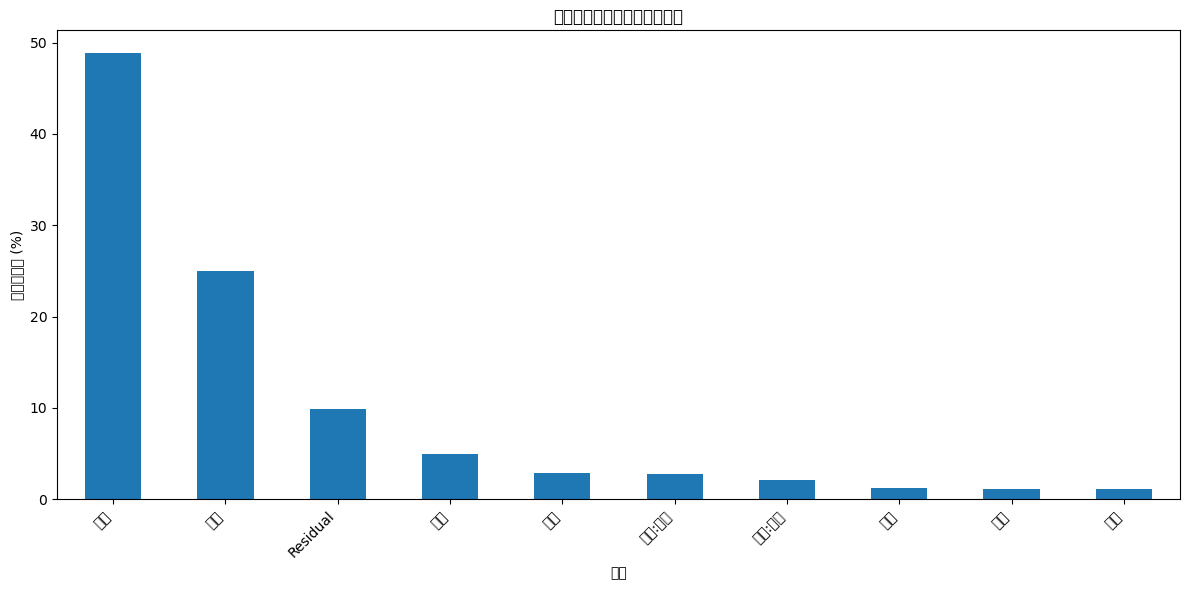

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

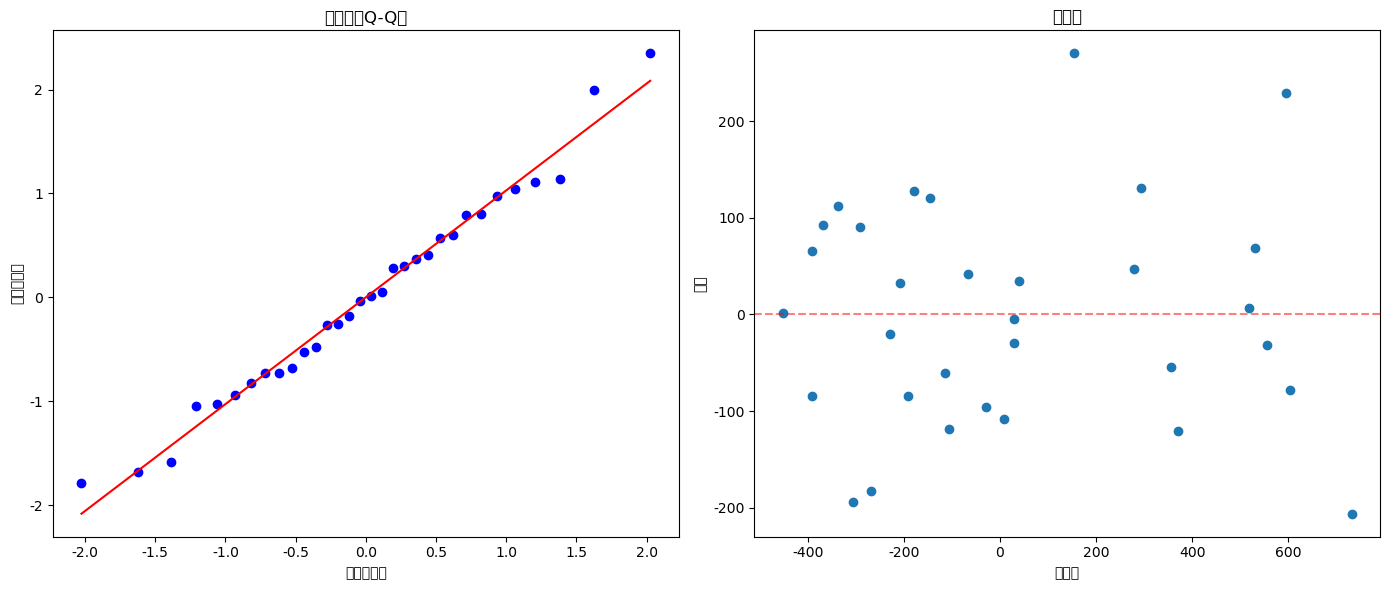

In [21]:
model = OLS_factor_DIY_model (df,[
    '红眼', 
    '橄榄',
    '气球', 
    
    '舞王', 
    '白眼', 
    # '投篮',
    '撑杆', 
    
    '密度',
],[
    # '红眼:橄榄',
    # '红眼:气球',
    # '红眼:舞王',
    # '红眼:白眼',
    # '红眼:投篮',
    # '红眼:撑杆',
    # '红眼:密度',


    '橄榄:气球',
    
    # '橄榄:舞王',
    # '橄榄:白眼',

    # '橄榄:投篮',
    
    '橄榄:撑杆',
    # '橄榄:密度',
    
])

In [22]:
pd.DataFrame(model.params)

,0
Intercept,32.03125
红眼,-38.28125
橄榄,-180.46875
气球,-252.34375
舞王,-38.28125
白眼,61.71875
撑杆,-39.84375
密度,-80.46875
橄榄:气球,60.15625
橄榄:撑杆,-52.34375


In [23]:
df

,Y,路障,撑杆,铁桶,读报,铁门,橄榄,舞王,潜水,冰车,...,矿工,跳跳,蹦极,扶梯,投篮,白眼,红眼,密度,residuals,fitted
0,425,1,-1,1,-1,-1,-1,1,-1,-1,...,1,-1,1,1,-1,-1,1,1,131.2500,293.7500
1,325,1,-1,1,-1,1,1,-1,-1,-1,...,-1,-1,1,1,1,1,1,-1,46.8750,278.1250
2,75,1,-1,-1,1,-1,1,1,-1,-1,...,-1,-1,-1,1,-1,1,1,1,34.3750,40.6250
3,-25,1,1,-1,1,1,-1,1,-1,-1,...,1,-1,-1,-1,-1,-1,1,-1,120.3125,-145.3125
4,25,1,-1,1,1,-1,-1,1,-1,-1,...,1,1,-1,-1,-1,1,-1,-1,-4.6875,29.6875
5,525,1,1,-1,1,1,-1,1,-1,-1,...,-1,-1,1,-1,1,1,1,-1,-78.1250,603.1250
6,-500,1,-1,-1,-1,-1,1,1,-1,-1,...,1,-1,-1,1,1,-1,1,-1,-193.7500,-306.2500
7,-275,1,1,1,-1,-1,1,1,-1,-1,...,-1,-1,1,1,-1,1,1,-1,92.1875,-367.1875
8,-125,1,1,-1,1,1,1,-1,-1,-1,...,-1,-1,1,1,-1,-1,1,-1,-95.3125,-29.6875
9,0,1,-1,1,-1,1,-1,-1,-1,-1,...,1,-1,-1,1,-1,1,1,-1,-29.6875,29.6875


In [24]:
model.predict(df).to_csv('2.1output.csv')

In [25]:
 (df,[
    '红眼', 
    '气球', 
    '橄榄',
    '投篮',
    '撑杆', 
    '舞王', 
    '白眼', 
],[
    '红眼:橄榄',
    
    '红眼:气球',
    '红眼:投篮',
    '红眼:撑杆',
    '红眼:舞王',
    '红眼:白眼',
    '红眼:密度',
    
    '橄榄:气球',
    '橄榄:投篮',
    '橄榄:撑杆',
    '橄榄:舞王',
    '橄榄:白眼',
    '橄榄:密度',
])

(      Y  路障  撑杆  铁桶  读报  铁门  橄榄  舞王  潜水  冰车  ...  矿工  跳跳  蹦极  扶梯  投篮  白眼  红眼  \
 0   425   1  -1   1  -1  -1  -1   1  -1  -1  ...   1  -1   1   1  -1  -1   1   
 1   325   1  -1   1  -1   1   1  -1  -1  -1  ...  -1  -1   1   1   1   1   1   
 2    75   1  -1  -1   1  -1   1   1  -1  -1  ...  -1  -1  -1   1  -1   1   1   
 3   -25   1   1  -1   1   1  -1   1  -1  -1  ...   1  -1  -1  -1  -1  -1   1   
 4    25   1  -1   1   1  -1  -1   1  -1  -1  ...   1   1  -1  -1  -1   1  -1   
 5   525   1   1  -1   1   1  -1   1  -1  -1  ...  -1  -1   1  -1   1   1   1   
 6  -500   1  -1  -1  -1  -1   1   1  -1  -1  ...   1  -1  -1   1   1  -1   1   
 7  -275   1   1   1  -1  -1   1   1  -1  -1  ...  -1  -1   1   1  -1   1   1   
 8  -125   1   1  -1   1   1   1  -1  -1  -1  ...  -1  -1   1   1  -1  -1   1   
 9     0   1  -1   1  -1   1  -1  -1  -1  -1  ...   1  -1  -1   1  -1   1   1   
 10  525   1  -1  -1   1   1  -1  -1  -1  -1  ...  -1   1  -1   1   1   1  -1   
 11  525   1   1   1   1   1